# Supervised Model Evaluation

This notebook evaluates the best-performing supervised model from development: the Random Forest classifier for predicting whether a complaint ends with monetary relief or non-monetary relief in CFPB consumer banking complaints.

AI Assistance:
OpenAI ChatGPT was used for code debugging, code generation, project organization,
and methodological brainstorming. All modeling, implementation,
validation, commentary, and interpretation were performed and verified by the authors.

## Notebook Overview

In this notebook, we will

1. restate the evaluation metrics and why they matter for this binary monetary-response target
2. review the saved model-family comparison from the development notebook
3. retrain the selected Random Forest using the same feature pipeline and evaluate it with cross-validation and a holdout split on the monetary-response dataset
4. analyze feature importance, ablation, hyperparameter sensitivity, and threshold tradeoffs
5. inspect specific failure cases and propose future improvements

## Table of Contents
1. [Evaluation Metrics](#Evaluation-Metrics)
2. [Model Comparison](#Model-Comparison)
3. [Best Model Deep Dive](#Best-Model-Deep-Dive)
4. [Feature Importance](#Feature-Importance)
5. [Ablation Analysis](#Ablation-Analysis)
6. [Sensitivity Analysis](#Sensitivity-Analysis)
7. [Tradeoff Analysis](#Tradeoff-Analysis)
8. [Failure Analysis](#Failure-Analysis)
9. [Conclusions](#Conclusions)

### Evaluation Metrics

Because this is still a classification problem with two response outcomes, we need more than accuracy to understand model quality. This evaluation reports:

- `accuracy` for overall correctness
- `precision` for how often predicted untimely cases are truly untimely
- `recall` for how many true untimely cases are captured
- `f1` as the primary model-selection metric because it balances precision and recall
- `roc_auc` to summarize ranking quality across thresholds
- `average_precision` because precision-recall behavior is informative under heavy imbalance
- `balanced_accuracy` so minority-class performance is not washed out by the majority class

Per the project requirements, model-family comparison should rely on cross-validated summary statistics. In this notebook, the saved development results provide that comparison, while the deeper evaluation focuses only on the selected Random Forest.

In [12]:
import ast
import os
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, learning_curve, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "consumer_banking_monetary_complaints.parquet"
COMPARISON_PATH = PROJECT_ROOT / "data" / "processed" / "monetary_supervised_model_comparison.csv"
MODEL_ARTIFACT_PATH = PROJECT_ROOT / "data" / "processed" / "best_monetary_response_model.joblib"
VISUALS_DIR = PROJECT_ROOT / "visuals"
VISUALS_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
CV_FOLDS = 5
FAST_CV_FOLDS = 3
N_JOBS = min(4, max(1, (os.cpu_count() or 2) - 1))

assert DATA_PATH.exists(), f"Expected source parquet at {DATA_PATH}"
raw_df = pd.read_parquet(DATA_PATH)
print(f"Loaded {len(raw_df):,} banking complaints from {DATA_PATH.name}")

Loaded 245,135 banking complaints from consumer_banking_monetary_complaints.parquet


### Model Comparison

The development notebook compared four model families using cross-validated metrics. We reload that saved comparison here so the overall-results section remains concise and consistent, then narrow the rest of the notebook to the selected Random Forest.

In [13]:
if COMPARISON_PATH.exists():
    comparison_df = pd.read_csv(COMPARISON_PATH)
    display(comparison_df)
    rf_comparison_row = comparison_df.loc[comparison_df["model_family"].eq("Random Forest")].copy()
    comparison_df.round(4).to_csv(VISUALS_DIR / "04_monetary_model_family_comparison.csv", index=False)
else:
    comparison_df = None
    rf_comparison_row = pd.DataFrame()
    print("Saved comparison table not found. Run the development notebook first if you want to display the model-family comparison here.")

rf_comparison_row

,model_family,best_params,cv_mean_accuracy,cv_std_accuracy,cv_mean_average_precision,cv_std_average_precision,cv_mean_roc_auc,cv_std_roc_auc,cv_mean_recall,cv_std_recall,cv_mean_precision,cv_std_precision,cv_mean_f1,cv_std_f1,cv_mean_balanced_accuracy,cv_std_balanced_accuracy,holdout_accuracy,holdout_average_precision,holdout_roc_auc,holdout_recall,holdout_precision,holdout_f1,holdout_balanced_accuracy
0,Random Forest,"{'model__max_depth': 20, 'model__max_features'...",0.789269,0.001131,0.868588,0.001097,0.861827,0.001117,0.930818,0.000555,0.756314,0.000996,0.834541,0.000820,0.765865,0.001232,0.790034,0.866422,0.860927,0.936015,0.754978,0.835806,0.765902
1,Support Vector Machine,{'model__C': 0.5},0.790381,0.001705,0.866268,0.001202,0.860639,0.001105,0.895191,0.001811,0.773365,0.001433,0.829830,0.001382,0.773051,0.001764,0.790422,0.864872,0.859129,0.896038,0.773007,0.829988,0.772962
2,Logistic Regression,{'model__C': 1.0},0.789886,0.001638,0.868185,0.001070,0.860872,0.001082,0.891806,0.002121,0.774390,0.001413,0.828960,0.001363,0.773035,0.001681,0.790972,0.866573,0.859425,0.893966,0.774634,0.830033,0.773946
3,KNN,"{'model__n_neighbors': 35, 'model__p': 2, 'mod...",0.747650,0.007013,0.801475,0.002473,0.799967,0.005185,0.901480,0.004142,0.724174,0.006772,0.803138,0.004681,0.722212,0.007987,0.750648,0.799682,0.802038,0.900539,0.727517,0.804834,0.725869


,model_family,best_params,cv_mean_accuracy,cv_std_accuracy,cv_mean_average_precision,cv_std_average_precision,cv_mean_roc_auc,cv_std_roc_auc,cv_mean_recall,cv_std_recall,cv_mean_precision,cv_std_precision,cv_mean_f1,cv_std_f1,cv_mean_balanced_accuracy,cv_std_balanced_accuracy,holdout_accuracy,holdout_average_precision,holdout_roc_auc,holdout_recall,holdout_precision,holdout_f1,holdout_balanced_accuracy
0,Random Forest,"{'model__max_depth': 20, 'model__max_features'...",0.789269,0.001131,0.868588,0.001097,0.861827,0.001117,0.930818,0.000555,0.756314,0.000996,0.834541,0.00082,0.765865,0.001232,0.790034,0.866422,0.860927,0.936015,0.754978,0.835806,0.765902


Even before the deeper analysis, the development comparison matters for the report because it shows that the selected model was not chosen from a single lucky split. The remainder of this notebook treats Random Forest as fixed and asks a different question: why does it behave the way it does, where does it fail, and what tradeoffs does it imply?

### Best Model Deep Dive

To keep evaluation consistent with development, we rebuild the same feature set and train/test split used in the development notebook. We keep only simple narrative indicators here, since more advanced narrative feature generation is being handled separately.

In [14]:
def make_one_hot_encoder():
    kwargs = {"handle_unknown": "ignore"}
    try:
        return OneHotEncoder(sparse_output=True, **kwargs)
    except TypeError:
        return OneHotEncoder(sparse=True, **kwargs)


def prepare_model_df(df):
    model_df = df.copy()
    model_df["Date received"] = pd.to_datetime(model_df["Date received"], errors="coerce")
    model_df["target_monetary_relief"] = model_df["Company response to consumer"].eq("Closed with monetary relief").astype(int)

    text_series = model_df["Consumer complaint narrative"].fillna("")
    model_df["narrative_present"] = text_series.str.len().gt(0).astype(int)
    model_df["narrative_char_count"] = text_series.str.len()
    model_df["narrative_word_count"] = text_series.str.split().str.len().fillna(0)

    model_df["received_year"] = model_df["Date received"].dt.year
    model_df["received_month"] = model_df["Date received"].dt.month
    model_df["received_quarter"] = model_df["Date received"].dt.quarter
    model_df["received_dayofweek"] = model_df["Date received"].dt.dayofweek
    model_df["received_day"] = model_df["Date received"].dt.day
    model_df["received_days_since_start"] = (
        model_df["Date received"] - model_df["Date received"].min()
    ).dt.days
    model_df["zip3"] = (
        model_df["ZIP code"].fillna("").astype(str).str.extract(r"(\d{3})", expand=False).fillna("missing")
    )

    top_category_limits = {
        "Company": 75,
        "Sub-product": 30,
        "Issue": 40,
        "Sub-issue": 60,
        "State": 30,
        "Tags": 10,
        "zip3": 100,
    }
    for col, top_n in top_category_limits.items():
        values = model_df[col].fillna("missing").astype(str)
        keep = set(values.value_counts().head(top_n).index)
        model_df[col] = values.where(values.isin(keep), other="__OTHER__")
    model_df["Submitted via"] = model_df["Submitted via"].fillna("missing").astype(str)
    model_df["Product"] = model_df["Product"].fillna("missing").astype(str)

    model_df = model_df.dropna(subset=["Date received", "target_monetary_relief"]).copy()
    return model_df


def score_predictions(y_true, y_pred, y_score):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "average_precision": average_precision_score(y_true, y_score),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
    }


def build_rf_pipeline(max_depth=None, min_samples_leaf=1, max_features="sqrt", selected_features=None):
    categorical_features = ["Product", "Sub-product", "Issue", "Sub-issue", "State", "Submitted via", "Tags", "zip3"]
    numeric_features = [
        "received_year",
        "received_month",
        "received_quarter",
        "received_dayofweek",
        "received_day",
        "received_days_since_start",
        "narrative_present",
        "narrative_char_count",
        "narrative_word_count",
    ]
    if selected_features is not None:
        selected_set = set(selected_features)
        categorical_features = [f for f in categorical_features if f in selected_set]
        numeric_features = [f for f in numeric_features if f in selected_set]

    transformers = []
    if categorical_features:
        transformers.append(
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", make_one_hot_encoder()),
                    ]
                ),
                categorical_features,
            )
        )
    if numeric_features:
        transformers.append(
            (
                "num",
                Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))]),
                numeric_features,
            )
        )

    preprocessor = ColumnTransformer(transformers=transformers)

    model = RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
    )
    return Pipeline(steps=[("preprocessor", preprocessor), ("model", model)]), categorical_features, numeric_features


default_best_params = {"max_depth": 20, "min_samples_leaf": 5, "max_features": "sqrt"}
if not rf_comparison_row.empty and "best_params" in rf_comparison_row.columns:
    try:
        parsed_params = ast.literal_eval(rf_comparison_row.iloc[0]["best_params"])
        best_rf_params = {
            "max_depth": parsed_params.get("model__max_depth", default_best_params["max_depth"]),
            "min_samples_leaf": parsed_params.get("model__min_samples_leaf", default_best_params["min_samples_leaf"]),
            "max_features": parsed_params.get("model__max_features", default_best_params["max_features"]),
        }
    except Exception:
        best_rf_params = default_best_params.copy()
else:
    best_rf_params = default_best_params.copy()

model_df = prepare_model_df(raw_df)
target_col = "target_monetary_relief"
train_df, test_df = train_test_split(
    model_df,
    test_size=0.2,
    stratify=model_df[target_col],
    random_state=RANDOM_STATE,
)

rf_pipeline, rf_categorical, rf_numeric = build_rf_pipeline(**best_rf_params)
rf_features = rf_categorical + rf_numeric
X_train = train_df[rf_features]
y_train = train_df[target_col]
X_test = test_df[rf_features]
y_test = test_df[target_col]

print(f"Modeling rows: {len(model_df):,}")
print(f"Train rows: {len(train_df):,}")
print(f"Test rows: {len(test_df):,}")
print(f"Monetary relief rate: {model_df[target_col].mean() * 100:.3f}%")
print(f"Random Forest params used for evaluation: {best_rf_params}")

Modeling rows: 245,135
Train rows: 196,108
Test rows: 49,027
Monetary relief rate: 57.094%
Random Forest params used for evaluation: {'max_depth': 20, 'min_samples_leaf': 5, 'max_features': 'sqrt'}


In [15]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "balanced_accuracy": "balanced_accuracy",
}
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_results = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    scoring=scoring,
    cv=cv,
    n_jobs=N_JOBS,
    return_train_score=False,
)

rf_pipeline.fit(X_train, y_train)
test_proba = rf_pipeline.predict_proba(X_test)[:, 1]
test_pred = rf_pipeline.predict(X_test)
holdout_metrics = score_predictions(y_test, test_pred, test_proba)

cv_summary = pd.DataFrame(
    {
        "metric": list(scoring.keys()),
        "cv_mean": [cv_results[f"test_{m}"].mean() for m in scoring],
        "cv_std": [cv_results[f"test_{m}"].std() for m in scoring],
        "holdout": [holdout_metrics[m] for m in scoring],
    }
).sort_values("metric").reset_index(drop=True)

cv_summary.round(4).to_csv(VISUALS_DIR / "04_monetary_random_forest_cv_summary.csv", index=False)
display(cv_summary)
print(classification_report(y_test, test_pred, digits=4))

,metric,cv_mean,cv_std,holdout
0,accuracy,0.789091,0.000618,0.790034
1,average_precision,0.869254,0.001727,0.866422
2,balanced_accuracy,0.765531,0.000681,0.765902
3,f1,0.834538,0.000459,0.835806
4,precision,0.755803,0.000622,0.754978
5,recall,0.931586,0.000745,0.936015
6,roc_auc,0.862202,0.001466,0.860927


              precision    recall  f1-score   support

           0     0.8750    0.5958    0.7089     21036
           1     0.7550    0.9360    0.8358     27991

    accuracy                         0.7900     49027
   macro avg     0.8150    0.7659    0.7723     49027
weighted avg     0.8065    0.7900    0.7813     49027



This section provides the core evaluation summary for the best model. The cross-validation columns satisfy the requirement that model performance should be summarized across multiple folds, while the holdout metrics show how the trained model behaves on unseen data from the same sampling pipeline.

### Feature Importance

Feature importance and ablation are especially useful here because the Random Forest can capture nonlinear interactions, but that flexibility also makes it harder to explain by inspection. We therefore look at both built-in tree importance and permutation-based importance.

In [16]:
fitted_preprocessor = rf_pipeline.named_steps["preprocessor"]
fitted_model = rf_pipeline.named_steps["model"]
feature_names = fitted_preprocessor.get_feature_names_out()

feature_importance_df = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": fitted_model.feature_importances_,
    }
).sort_values("importance", ascending=False)

feature_importance_df["feature_group"] = feature_importance_df["feature"].str.split("__").str[1].str.split("_").str[0]
group_importance_df = (
    feature_importance_df.groupby("feature_group", dropna=False)["importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

perm_subset_X = X_test.sample(n=min(5000, len(X_test)), random_state=RANDOM_STATE)
perm_subset_y = y_test.loc[perm_subset_X.index]
perm = permutation_importance(
    rf_pipeline,
    perm_subset_X,
    perm_subset_y,
    scoring="f1",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
)
perm_df = pd.DataFrame(
    {
        "feature": rf_features,
        "permutation_importance_mean": perm.importances_mean,
        "permutation_importance_std": perm.importances_std,
    }
).sort_values("permutation_importance_mean", ascending=False)

feature_importance_df.head(20).round(6).to_csv(VISUALS_DIR / "04_monetary_feature_importance_top20.csv", index=False)
group_importance_df.round(6).to_csv(VISUALS_DIR / "04_monetary_feature_group_importance.csv", index=False)
perm_df.round(6).to_csv(VISUALS_DIR / "04_monetary_permutation_importance.csv", index=False)
display(feature_importance_df.head(20))
display(group_importance_df)
display(perm_df)

,feature,importance,feature_group
43,cat__Issue_Getting a credit card,0.076827,Issue
46,cat__Issue_Incorrect information on your report,0.076157,Issue
62,cat__Issue_Problem with a purchase shown on yo...,0.058290,Issue
130,cat__Sub-issue_Was not notified of investigati...,0.055652,Sub-issue
58,cat__Issue_Problem with a company's investigat...,0.049632,Issue
42,cat__Issue_Fees or interest,0.038795,Issue
76,cat__Sub-issue_Account status incorrect,0.036234,Sub-issue
92,cat__Sub-issue_Credit card company isn't resol...,0.035967,Sub-issue
13,cat__Sub-product_General-purpose credit card o...,0.030479,Sub-product
8,cat__Sub-product_Checking account,0.030159,Sub-product


,feature_group,importance
0,Issue,0.387068
1,Sub-issue,0.317347
2,Sub-product,0.068578
3,Product,0.064499
4,received,0.061695
5,narrative,0.055726
6,Submitted via,0.016450
7,State,0.011384
8,zip3,0.009272
9,Tags,0.007980


,feature,permutation_importance_mean,permutation_importance_std
2,Issue,0.063623,0.003159
3,Sub-issue,0.017697,0.002247
0,Product,0.001512,0.001651
8,received_year,0.001245,0.001125
1,Sub-product,0.001040,0.000844
5,Submitted via,0.000741,0.000065
6,Tags,0.000151,0.000302
13,received_days_since_start,0.000086,0.001649
14,narrative_present,-0.000069,0.000416
15,narrative_char_count,-0.000142,0.000755


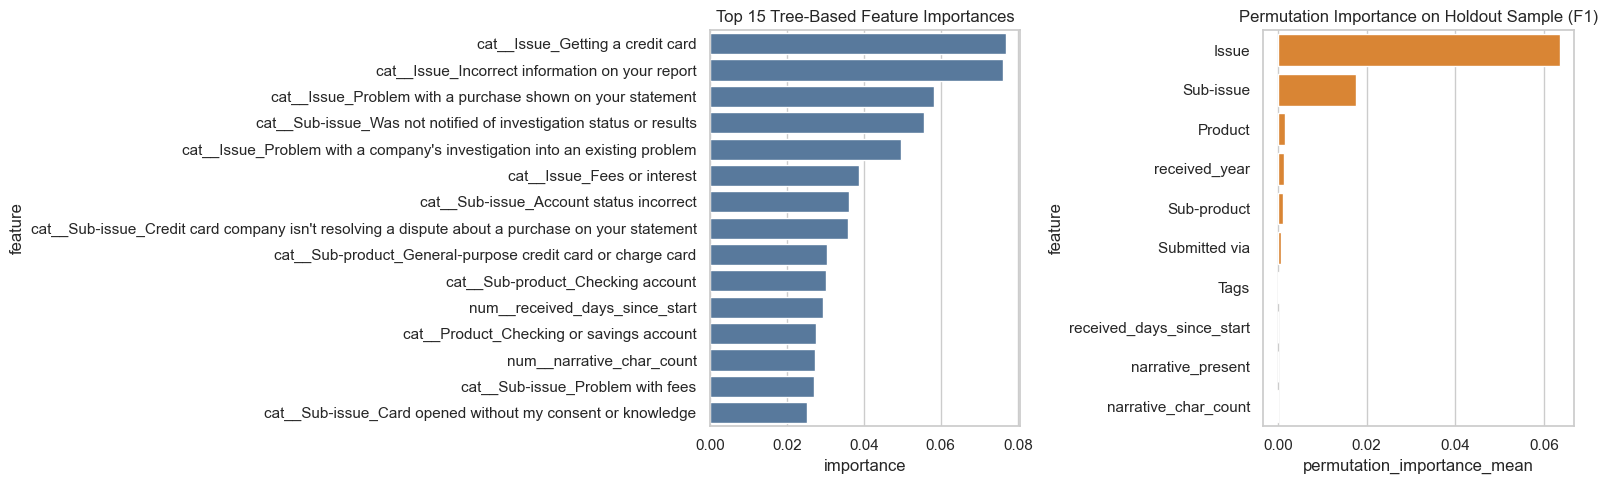

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=feature_importance_df.head(15), x="importance", y="feature", ax=axes[0], color="#4C78A8")
axes[0].set_title("Top 15 Tree-Based Feature Importances")

sns.barplot(data=perm_df.head(10), x="permutation_importance_mean", y="feature", ax=axes[1], color="#F58518")
axes[1].set_title("Permutation Importance on Holdout Sample (F1)")
plt.tight_layout()

A strong evaluation should connect importance results back to modeling choices. In this project, the key question is whether untimely predictions are driven more by complaint context such as issue type and submission channel, or by geography and the simple narrative indicators. The grouped importance table is especially helpful for answering that report-level question.

### Ablation Analysis

Ablation testing measures how much the model depends on different groups of features. To keep runtime reasonable, this section uses a 3-fold CV summary on the training set and compares F1 after removing one feature family at a time.

In [18]:
feature_groups = {
    "all_features": rf_features,
    "no_narrative": [f for f in rf_features if not f.startswith("narrative_")],
    "no_geography": [f for f in rf_features if f not in {"State", "zip3"}],
    "no_product_context": [f for f in rf_features if f not in {"Product", "Sub-product"}],
    "no_issue_context": [f for f in rf_features if f not in {"Issue", "Sub-issue"}],
}

ablation_rows = []
fast_cv = StratifiedKFold(n_splits=FAST_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
for label, cols in feature_groups.items():
    ablation_pipeline, _, _ = build_rf_pipeline(selected_features=cols, **best_rf_params)
    scores = cross_validate(
        ablation_pipeline,
        train_df[cols],
        y_train,
        scoring={"f1": "f1", "recall": "recall", "precision": "precision"},
        cv=fast_cv,
        n_jobs=N_JOBS,
        return_train_score=False,
    )
    ablation_rows.append(
        {
            "ablation": label,
            "cv_mean_f1": scores["test_f1"].mean(),
            "cv_mean_precision": scores["test_precision"].mean(),
            "cv_mean_recall": scores["test_recall"].mean(),
            "feature_count": len(cols),
        }
    )

ablation_df = pd.DataFrame(ablation_rows).sort_values("cv_mean_f1", ascending=False).reset_index(drop=True)
baseline_f1 = ablation_df.loc[ablation_df["ablation"].eq("all_features"), "cv_mean_f1"].iloc[0]
ablation_df["f1_drop_vs_all_features"] = baseline_f1 - ablation_df["cv_mean_f1"]
ablation_df.round(4).to_csv(VISUALS_DIR / "04_monetary_ablation_results.csv", index=False)
display(ablation_df)

,ablation,cv_mean_f1,cv_mean_precision,cv_mean_recall,feature_count,f1_drop_vs_all_features
0,no_geography,0.835500,0.762019,0.924665,15,-0.000958
1,all_features,0.834541,0.756314,0.930818,17,0.000000
2,no_narrative,0.833687,0.754492,0.931461,14,0.000854
3,no_product_context,0.832933,0.740945,0.951003,15,0.001609
4,no_issue_context,0.771585,0.688222,0.877945,15,0.062957


### Sensitivity Analysis

Sensitivity analysis helps us understand whether the selected Random Forest is stable or fragile. Here we vary two influential hyperparameters, `max_depth` and `min_samples_leaf`, and track cross-validated F1. A stable model should not collapse from small changes around the selected setting.

,max_depth,min_samples_leaf,cv_mean_f1,cv_mean_precision,cv_mean_recall
3,20,1,0.835812,0.760346,0.927921
4,20,5,0.835528,0.756759,0.932605
7,None,5,0.834237,0.765673,0.916298
0,12,1,0.831135,0.736346,0.953942
1,12,5,0.830833,0.735818,0.954029
5,20,20,0.830305,0.742851,0.941105
8,None,20,0.830153,0.744836,0.937549
6,None,1,0.829166,0.775465,0.890884
2,12,20,0.827096,0.728615,0.956371


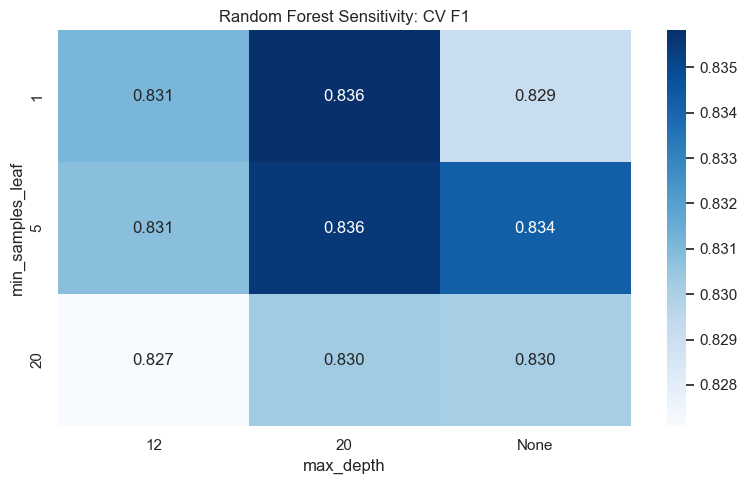

In [19]:
sensitivity_rows = []
sensitivity_train_df = train_df.sample(n=min(20000, len(train_df)), random_state=RANDOM_STATE)
sensitivity_y = sensitivity_train_df[target_col]
for max_depth in [12, 20, None]:
    for min_samples_leaf in [1, 5, 20]:
        pipeline, _, _ = build_rf_pipeline(max_depth=max_depth, min_samples_leaf=min_samples_leaf, max_features=best_rf_params["max_features"])
        scores = cross_validate(
            pipeline,
            sensitivity_train_df[rf_features],
            sensitivity_y,
            scoring={"f1": "f1", "recall": "recall", "precision": "precision"},
            cv=fast_cv,
            n_jobs=N_JOBS,
            return_train_score=False,
        )
        sensitivity_rows.append(
            {
                "max_depth": str(max_depth),
                "min_samples_leaf": min_samples_leaf,
                "cv_mean_f1": scores["test_f1"].mean(),
                "cv_mean_precision": scores["test_precision"].mean(),
                "cv_mean_recall": scores["test_recall"].mean(),
            }
        )

sensitivity_df = pd.DataFrame(sensitivity_rows).sort_values(["cv_mean_f1", "cv_mean_recall"], ascending=False)
sensitivity_df.round(4).to_csv(VISUALS_DIR / "04_monetary_sensitivity_results.csv", index=False)
display(sensitivity_df)

pivot_f1 = sensitivity_df.pivot(index="min_samples_leaf", columns="max_depth", values="cv_mean_f1")
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_f1, annot=True, fmt=".3f", cmap="Blues")
plt.title("Random Forest Sensitivity: CV F1")
plt.ylabel("min_samples_leaf")
plt.xlabel("max_depth")
plt.tight_layout()
plt.savefig(VISUALS_DIR / "04_monetary_sensitivity_heatmap.png", dpi=200, bbox_inches="tight")

### Tradeoff Analysis

Tradeoff analysis asks how the Random Forest behaves when we change decision thresholds or training data size. This is still useful even with a more balanced target, because threshold shifts can change the precision-recall tradeoff materially.

,setting,accuracy,precision,recall,f1,balanced_accuracy
0,default_0.50,0.790034,0.754978,0.936015,0.835806,0.765902
1,best_f1_0.494,0.789320,0.751854,0.941838,0.836191,0.764107


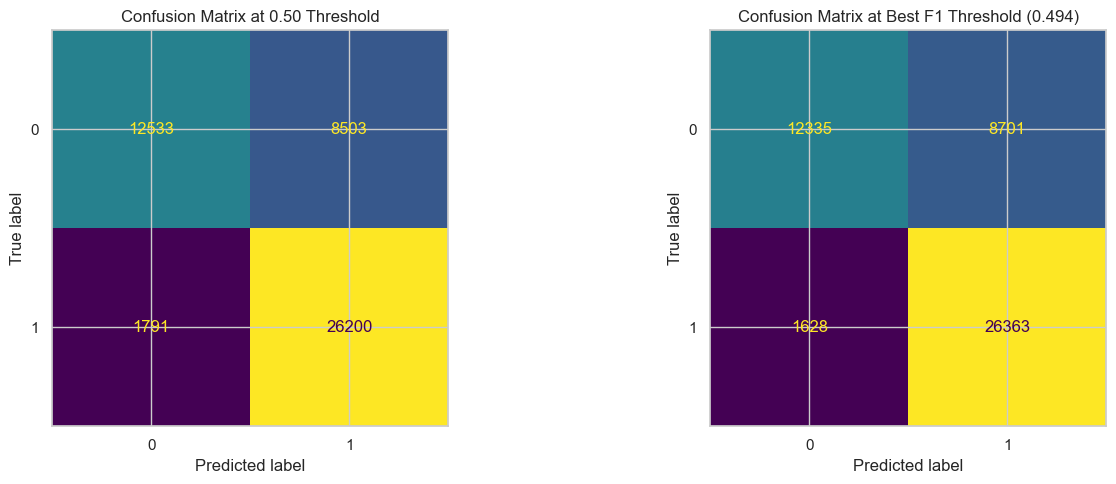

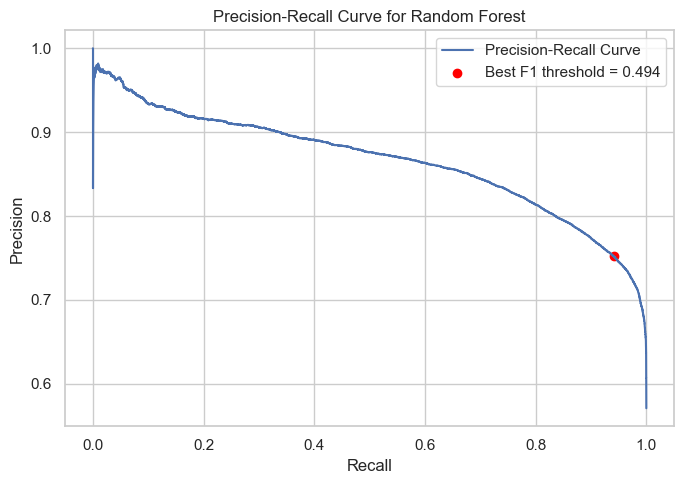

In [20]:
precisions, recalls, thresholds = precision_recall_curve(y_test, test_proba)
threshold_f1 = np.divide(
    2 * precisions[:-1] * recalls[:-1],
    precisions[:-1] + recalls[:-1],
    out=np.zeros_like(precisions[:-1]),
    where=(precisions[:-1] + recalls[:-1]) != 0,
)
best_threshold_idx = int(np.argmax(threshold_f1))
best_threshold = float(thresholds[best_threshold_idx])
threshold_pred = (test_proba >= best_threshold).astype(int)
threshold_metrics = score_predictions(y_test, threshold_pred, test_proba)

threshold_tradeoff_df = pd.DataFrame(
    {
        "setting": ["default_0.50", f"best_f1_{best_threshold:.3f}"],
        "accuracy": [holdout_metrics["accuracy"], threshold_metrics["accuracy"]],
        "precision": [holdout_metrics["precision"], threshold_metrics["precision"]],
        "recall": [holdout_metrics["recall"], threshold_metrics["recall"]],
        "f1": [holdout_metrics["f1"], threshold_metrics["f1"]],
        "balanced_accuracy": [holdout_metrics["balanced_accuracy"], threshold_metrics["balanced_accuracy"]],
    }
)
threshold_tradeoff_df.round(4).to_csv(VISUALS_DIR / "04_monetary_threshold_tradeoff.csv", index=False)
display(threshold_tradeoff_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_test, test_pred, ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix at 0.50 Threshold")
ConfusionMatrixDisplay.from_predictions(y_test, threshold_pred, ax=axes[1], colorbar=False)
axes[1].set_title(f"Confusion Matrix at Best F1 Threshold ({best_threshold:.3f})")
plt.tight_layout()
fig.savefig(VISUALS_DIR / "04_monetary_confusion_matrices.png", dpi=200, bbox_inches="tight")

plt.figure(figsize=(7, 5))
plt.plot(recalls, precisions, label="Precision-Recall Curve")
plt.scatter(recalls[best_threshold_idx], precisions[best_threshold_idx], color="red", label=f"Best F1 threshold = {best_threshold:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Random Forest")
plt.legend()
plt.tight_layout()
plt.savefig(VISUALS_DIR / "04_monetary_precision_recall_curve.png", dpi=200, bbox_inches="tight")

,train_size,train_f1_mean,validation_f1_mean
0,2666,0.858623,0.825422
1,5333,0.855644,0.829683
2,7999,0.856434,0.834129
3,10666,0.854873,0.834910
4,13333,0.852088,0.834647


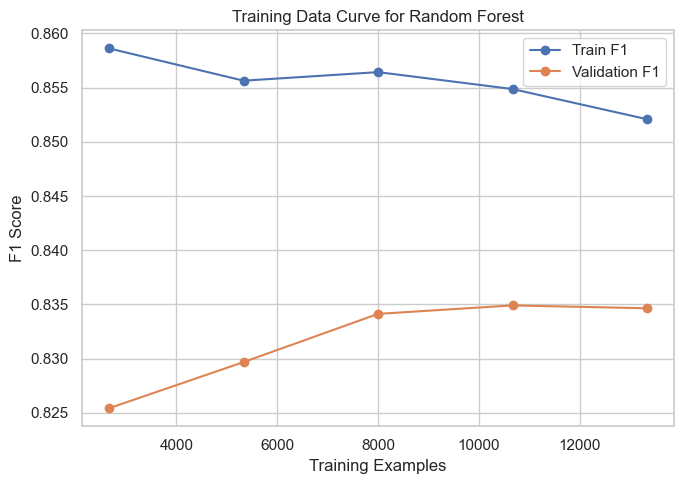

In [21]:
curve_train_df = train_df.sample(n=min(20000, len(train_df)), random_state=RANDOM_STATE)
curve_y = curve_train_df[target_col]
curve_pipeline, _, _ = build_rf_pipeline(**best_rf_params)
train_sizes, train_scores, valid_scores = learning_curve(
    curve_pipeline,
    curve_train_df[rf_features],
    curve_y,
    train_sizes=np.linspace(0.2, 1.0, 5),
    cv=fast_cv,
    scoring="f1",
    n_jobs=N_JOBS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

learning_curve_df = pd.DataFrame(
    {
        "train_size": train_sizes,
        "train_f1_mean": train_scores.mean(axis=1),
        "validation_f1_mean": valid_scores.mean(axis=1),
    }
)
learning_curve_df.round(4).to_csv(VISUALS_DIR / "04_monetary_learning_curve.csv", index=False)
display(learning_curve_df)

plt.figure(figsize=(7, 5))
plt.plot(learning_curve_df["train_size"], learning_curve_df["train_f1_mean"], marker="o", label="Train F1")
plt.plot(learning_curve_df["train_size"], learning_curve_df["validation_f1_mean"], marker="o", label="Validation F1")
plt.xlabel("Training Examples")
plt.ylabel("F1 Score")
plt.title("Training Data Curve for Random Forest")
plt.legend()
plt.tight_layout()
plt.savefig(VISUALS_DIR / "04_monetary_learning_curve.png", dpi=200, bbox_inches="tight")

This section captures multiple project-required tradeoffs:

- precision versus recall as the classification threshold changes
- conservative default thresholding versus threshold tuning for minority-class detection
- training data size versus validation F1 through the learning curve

Together, these analyses help explain whether the model is limited more by representation, thresholding, or simply available data.

### Failure Analysis

Failure analysis focuses on specific mistakes rather than aggregate metrics. To satisfy the assignment requirement, we select at least three concrete failed predictions and group them into different categories. The goal is not just to note the error, but to reason about why it likely occurred and what future improvements could address it.

In [22]:
failure_df = test_df[[
    "Complaint ID",
    "Product",
    "Sub-product",
    "Issue",
    "Sub-issue",
    "Company",
    "State",
    "Submitted via",
    "Consumer complaint narrative",
    target_col,
]].copy()
failure_df["predicted_label"] = test_pred
failure_df["predicted_proba"] = test_proba
failure_df["error_type"] = np.where(
    (failure_df[target_col] == 1) & (failure_df["predicted_label"] == 0),
    "false_negative",
    np.where(
        (failure_df[target_col] == 0) & (failure_df["predicted_label"] == 1),
        "false_positive",
        "correct",
    ),
)
failure_df["narrative_present"] = failure_df["Consumer complaint narrative"].fillna("").str.len().gt(0)
failure_df["narrative_word_count"] = failure_df["Consumer complaint narrative"].fillna("").str.split().str.len().fillna(0)

false_negative_examples = failure_df.loc[failure_df["error_type"].eq("false_negative")].sort_values("predicted_proba", ascending=False)
false_positive_examples = failure_df.loc[failure_df["error_type"].eq("false_positive")].sort_values("predicted_proba", ascending=False)

failure_examples = pd.concat(
    [
        false_negative_examples.head(1).assign(failure_category="likely systematic minority-class miss"),
        false_positive_examples.head(1).assign(failure_category="aggressive positive flag / ambiguous case"),
        false_negative_examples.sort_values("narrative_word_count").head(1).assign(failure_category="sparse-information edge case"),
    ],
    axis=0,
).drop_duplicates(subset=["Complaint ID"]).reset_index(drop=True)

failure_examples.to_csv(VISUALS_DIR / "04_monetary_failure_examples.csv", index=False)
display(failure_examples[[
    "Complaint ID",
    "failure_category",
    "error_type",
    target_col,
    "predicted_label",
    "predicted_proba",
    "Product",
    "Issue",
    "Sub-issue",
    "State",
    "Submitted via",
    "narrative_present",
    "narrative_word_count",
]])

,Complaint ID,failure_category,error_type,target_monetary_relief,predicted_label,predicted_proba,Product,Issue,Sub-issue,State,Submitted via,narrative_present,narrative_word_count
0,3399761,likely systematic minority-class miss,false_negative,1,0,0.499988,Mortgage,Trouble during payment process,missing,CA,Web,False,0
1,3104586,aggressive positive flag / ambiguous case,false_positive,0,1,0.956021,Checking or savings account,Problem caused by your funds being low,Overdrafts and overdraft fees,IL,Referral,False,0
2,2177962,sparse-information edge case,false_negative,1,0,0.499278,Mortgage,"Loan servicing, payments, escrow account",missing,CA,Phone,False,0


Use the displayed failure cases to write the final report narrative in a structured way:

1. Describe the record and the incorrect prediction.
2. Note whether the failure looks more like a systematic minority-class miss, an edge case with weak information, or an overly aggressive positive flag.
3. Connect that failure back to evidence from feature importance, threshold analysis, or data imbalance.
4. Propose a future fix, such as threshold adjustment, richer narrative features, additional data, or different sampling/ensemble strategies.

Practical interpretation hints:

- False negatives usually support the argument that the default threshold is conservative or that rare-class signal is underrepresented.
- False positives often suggest overlapping patterns between timely and untimely complaints for certain issue or company contexts.
- Very short or missing narratives can create edge cases because the model has less descriptive context available, even when simple narrative indicators are included.

### Conclusions

This notebook covers the main evaluation requirements for the selected Random Forest:

- overall model comparison via the saved cross-validated development table
- detailed evaluation using cross-validation plus holdout metrics
- feature importance and feature-group ablation
- hyperparameter sensitivity analysis
- threshold and training-data tradeoff analysis
- concrete failure examples and future-improvement directions

For the written report, the most useful takeaways will likely be:

- whether issue/sub-issue context or simple narrative indicators drive the Random Forest most strongly
- whether threshold tuning materially improves recall or F1 for the rare untimely-response class
- whether the learning curve suggests diminishing returns or continued gains from more data
- which recurring failure categories point to the next best improvements